# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Bas Flikkema
* Username: bflikkema
* Student number: s5998662
* Group (AS1, etc.): AS3

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

Filename: ngc6946.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     206   (100, 100, 101)   int16 (rescales to float32)   


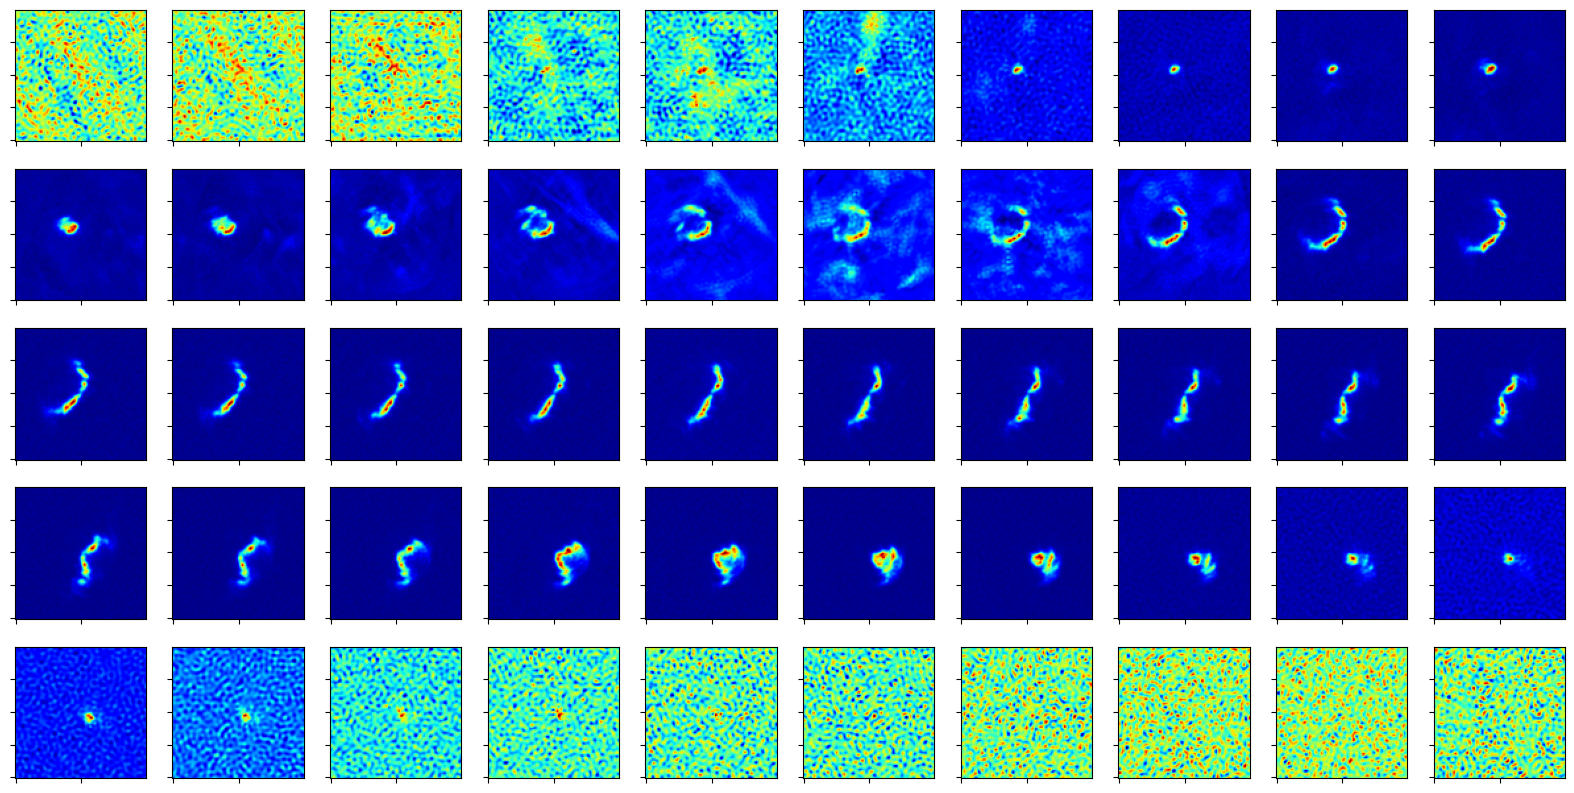

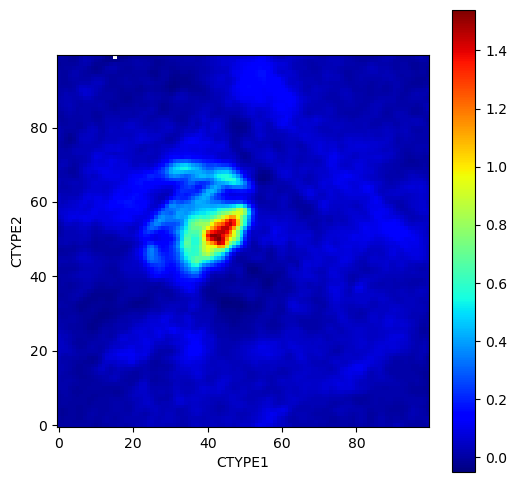

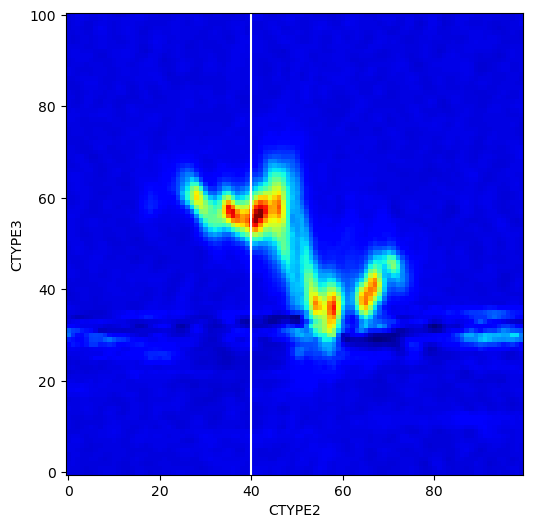

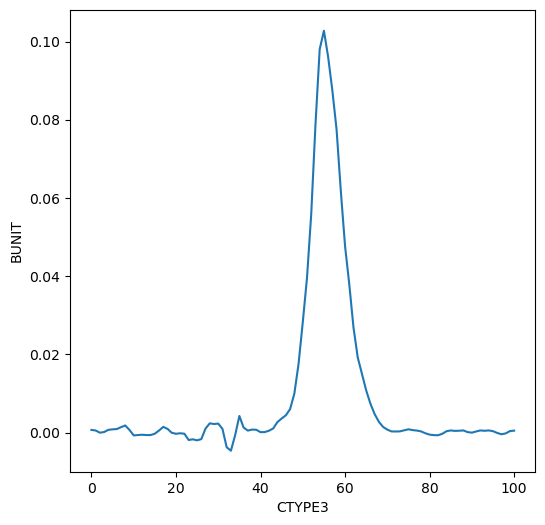

In [40]:
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
hdulist = fits.open('ngc6946.fits')
hdulist.info()
# Since we want to apply the slice to the Z-elements, we seperate this data.
data_z = hdulist[0].data
data_points_z = list(range(1,101,2)) 
# Set up the mosaic structure
fig, axes = plt.subplots(5, 10, figsize = (20,10))
axes = axes.flatten()                # This way, we don't have to direct data to two "coordinates", 0 is the first box, 49 is the last box now.
# Set up a for loop that will assign the data to the subplots.
for i, idx in enumerate(data_points_z):
    ax = axes[i]      
    channel_slice = data_z[idx,:,:] 
    ax.imshow(channel_slice, origin = 'lower', cmap = 'jet')  # Connects the data from index 1 to subplot 0, data from index 3 to subplot 1 and so on.
    ax.set_xticklabels([])
    ax.set_yticklabels([])
plt.show()
# Make a sum of the selected data, starting from the ninth plot in the first row, and ending on the ninth row of the fourth row.

fig, axes = plt.subplots(figsize = (6,6))
useful_data = np.sum(data_z[8:38:1,:,:], axis = 0)
image = axes.imshow(useful_data, origin = 'lower', cmap = 'jet')
axes.set_xlabel("CTYPE1")
axes.set_ylabel("CTYPE2")
fig.colorbar(image)
plt.show()
# Right ascension is connected to the x-axis, so we set this to the given value.
pv1 = data_z[:,:,50]
fig, axes = plt.subplots(figsize = (6,6))
image2 = axes.imshow(pv1, origin = 'lower', cmap = 'jet')
axes.set_xlabel("CTYPE2")
axes.set_ylabel("CTYPE3")
axes.axvline(40, color = 'white')    # Adds a line at declanation of 40.
plt.show()
# Set up the slice for the global profile
global_profile = data_z[:,40,50]
fig, axes = plt.subplots(figsize = (6,6))
global_plot = axes.plot(global_profile)
axes.set_xlabel("CTYPE3")
axes.set_ylabel("BUNIT")
plt.show()
# The connection between the verical line and the global profile is that they have a peak at the same value. In the image this is shown by more intense color in the global profile by an actual peak.

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

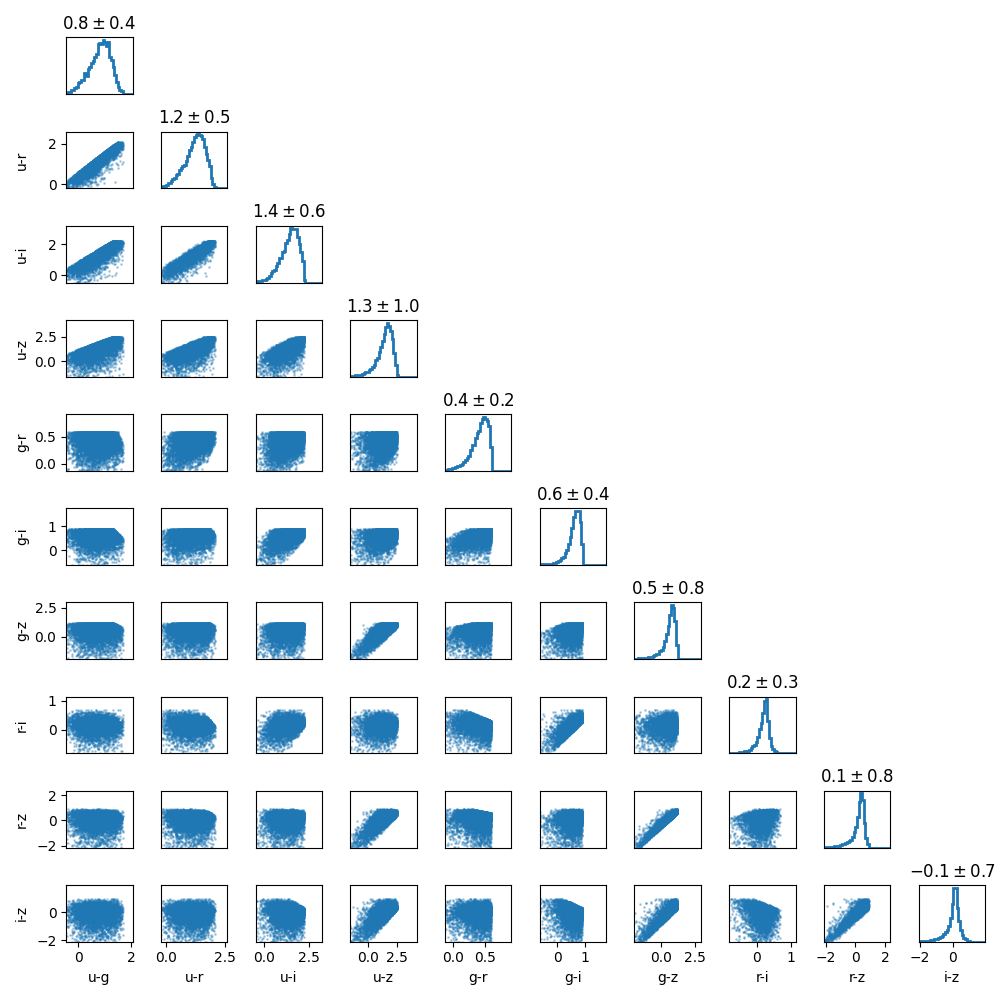
   
**Plot and answer**:

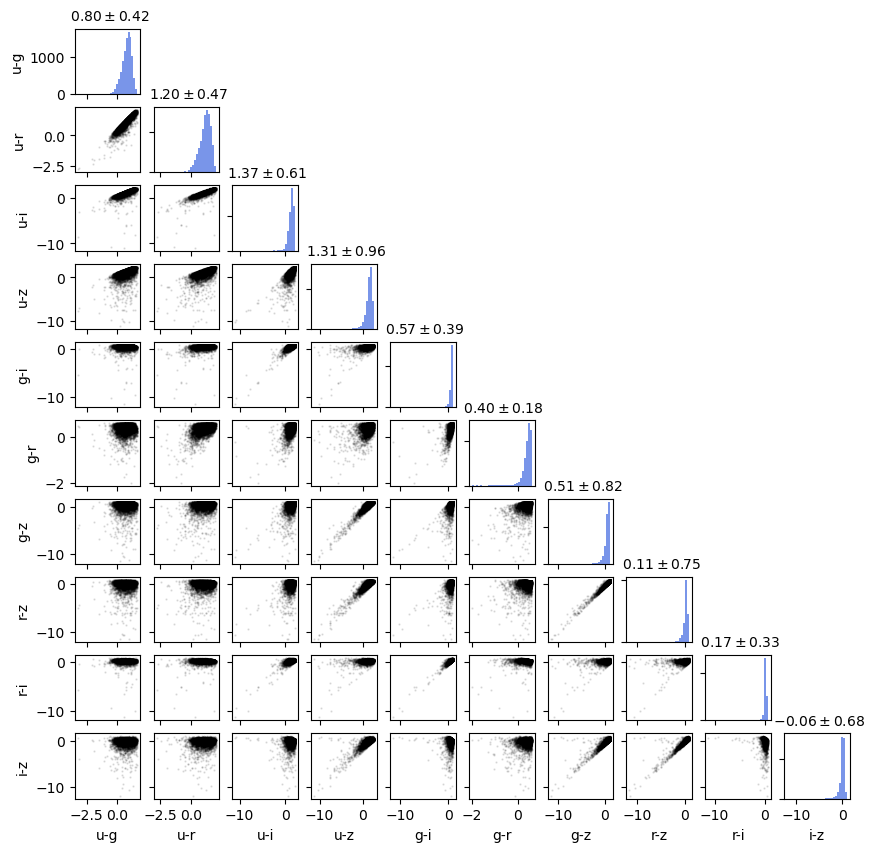

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
hdulist = fits.open('SDSS_DR17_galaxies.fits')
#hdulist.info()      # Checking the data
data = hdulist[1].data          # Use index 1, as header 0 does not give information.
df = Table(data).to_pandas() 
filtered_df = df[(df['u'] >= 0) & (df['g'] >= 0) & (df['r'] >=0) & (df['i'] >= 0) & (df['z'] >= 0)]    # Takes out all negative values.
# Making the subtractions
u_g = filtered_df['u'] - filtered_df['g']
u_r = filtered_df['u'] - filtered_df['r']
u_i = filtered_df['u'] - filtered_df['i']
u_z = filtered_df['u'] - filtered_df['z']

g_i = filtered_df['g'] - filtered_df['i']
g_r = filtered_df['g'] - filtered_df['r']
g_z = filtered_df['g'] - filtered_df['z']

r_z = filtered_df['r'] - filtered_df['z']
r_i = filtered_df['r'] - filtered_df['i']

i_z = filtered_df['i'] - filtered_df['z']
# Calculating the means and standard deviations.
mean_u_g = np.mean(u_g)
std_u_g = np.std(u_g)
mean_u_r = np.mean(u_r)
std_u_r = np.std(u_r)
mean_u_i = np.mean(u_i)
std_u_i = np.std(u_i)
mean_u_z = np.mean(u_z)
std_u_z = np.std(u_z)

mean_g_i = np.mean(g_i)
std_g_i = np.std(g_i)
mean_g_r = np.mean(g_r)
std_g_r = np.std(g_r)
mean_g_z = np.mean(g_z)
std_g_z = np.std(g_z)

mean_r_z = np.mean(r_z)
std_r_z = np.std(r_z)
mean_r_i = np.mean(r_i)
std_r_i = np.std(r_i)

mean_i_z = np.mean(i_z)
std_i_z = np.std(i_z)
means = [mean_u_g, mean_u_r, mean_u_i, mean_u_z, mean_g_i, mean_g_r, mean_g_z, mean_r_z, mean_r_i, mean_i_z]
stds = [std_u_g, std_u_r, std_u_i, std_u_z, std_g_i, std_g_r, std_g_z, std_r_z, std_r_i, std_i_z]
# Now we set up the plot
plot_data = [u_g, u_r, u_i, u_z, g_i, g_r, g_z, r_z, r_i, i_z]
labels = ['u-g', 'u-r', 'u-i', 'u-z', 'g-i', 'g-r', 'g-z', 'r-z', 'r-i', 'i-z']
n = len(plot_data)

fig, axes = plt.subplots( n, n, figsize = (10,10))
# Use a for loop to go through all the subplots in the 10 by 10 frame.
for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        
# Add this condition, such that we get the corner structure and an empty 'upper triangle'
        if j > i:
            ax.set_axis_off()
            continue
            
        # Here there is the same color on the x-axis as the y-axis so we need a histogram.
        if i == j:
            ax.hist(plot_data[i], bins=30, color='royalblue', alpha=0.7)
            ax.set_title(f" ${means[i]:.2f} \pm {stds[i]:.2f}$", fontsize = 10)
            
            
        # Here there are two different colors on the axes, so we need a scatter.
        else:
            ax.scatter(plot_data[j], plot_data[i], s=0.5, alpha=0.1, color='black')
        
       
        # Only show x-labels on the bottom row, to not hinder the other plots.
        if i == n - 1:
            ax.set_xlabel(labels[j], fontsize=10)
        else:
            ax.set_xticklabels([])
            
        # Only show y-labels on the first column, again to not hinder the other plots.
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=10)
        else:
            ax.set_yticklabels([])
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

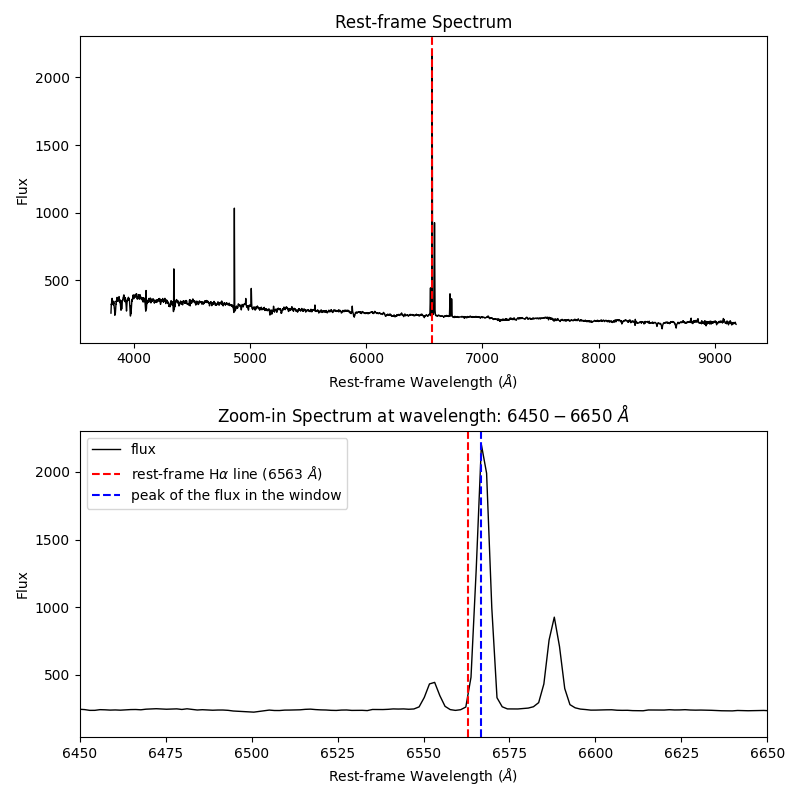

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     141   ()      
  1  COADD         1 BinTableHDU     26   3831R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPECOBJ       1 BinTableHDU    262   1R x 126C   [6A, 4A, 16A, 23A, 16A, 8A, E, E, E, J, E, E, J, B, B, B, B, B, B, J, 22A, 19A, 19A, 22A, 19A, I, 3A, 3A, 1A, J, D, D, D, E, E, 19A, 8A, J, J, J, J, K, K, J, J, J, J, J, J, K, K, K, K, I, J, J, J, J, 5J, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, E, 5E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 25A, 21A, 10A, E, E, E, E, E, E, E, E, J, E, E, J, 1A, 1A, E, E, J, J, 1A, 5E, 5E]   
  3  SPZLINE       1 BinTableHDU     48   29R x 19C   [J, J, J, 13A, D, E, E, E, E, E, E, E, E, E, E, J, J, E, E]   
  4  B2-00023182-00023180-00023181    1 BinTableHDU    146   2047R x 7C   [E, E, E, J, E, E, E]   
  5  B2-00023183-00023180-00023181    1 BinTa

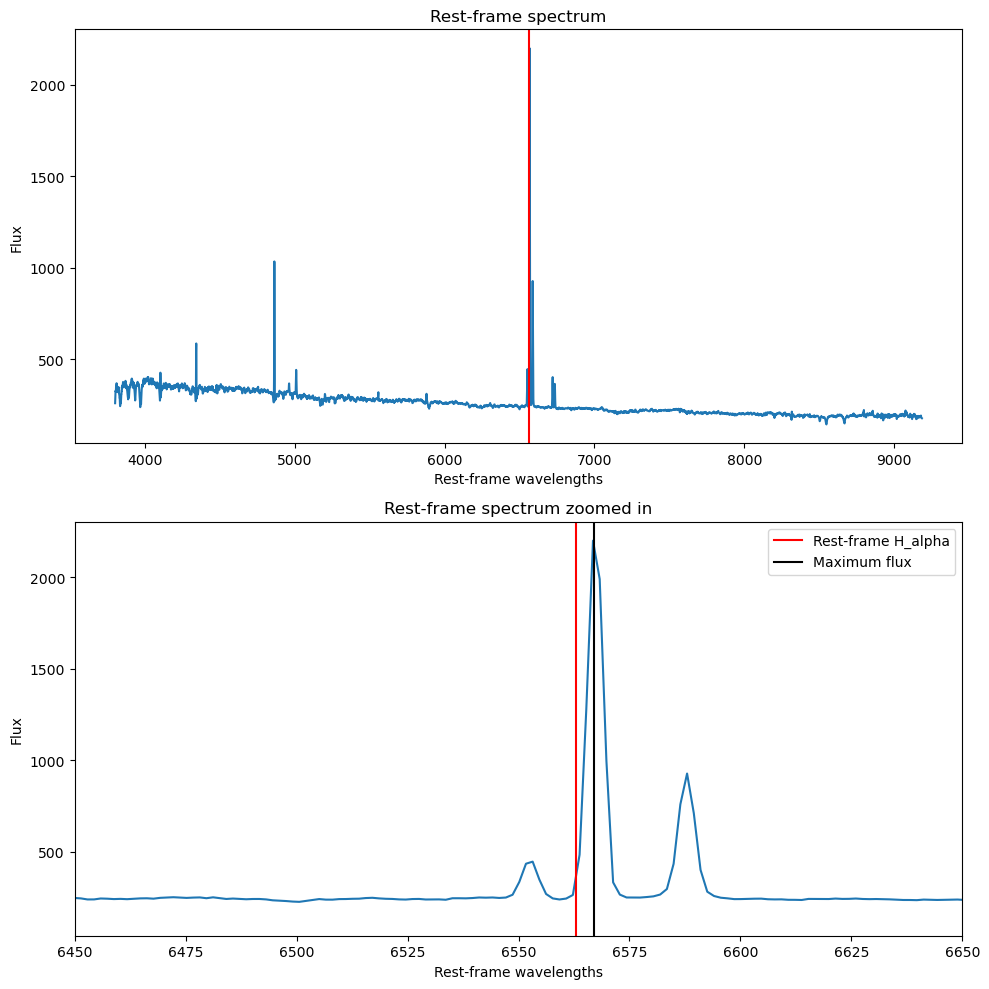

The velocity of the galaxy is: [1134900.1 1134907.5 1134914.8 ... 1134897.2 1134921.5 1134914.6] m/s


In [50]:
from astropy import coordinates as coords
from astropy import units as u

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
from astroquery.sdss import SDSS
search = SDSS.query_region(pos, radius = 10 * u.arcsec, spectro = True)
spectra = SDSS.get_spectra(matches=search)
spectra[0].info()       #Check the data from spectra
spectral_data = spectra[0][1].data
flux = spectral_data['flux']
wavelength = 10**spectral_data['loglam']   # Use 10** to correct for the log element
z = 0.0038
wavelength_rest = wavelength/(1+z)         # Rewrote the formula for redshift
from matplotlib import pyplot as plt
fig, ax = plt.subplots(2, 1, figsize = (10,10))
axes = ax.flatten()
# Giving characteristics to the first plot.
axes[0].plot(wavelength_rest, flux)
axes[0].set_title('Rest-frame spectrum')
axes[0].set_ylabel('Flux')
axes[0].set_xlabel('Rest-frame wavelengths')
axes[0].axvline(6563, color = 'red')
# Giving characteristics to the second plot.
axes[1].plot(wavelength_rest, flux)
axes[1].set_title('Rest-frame spectrum zoomed in')
axes[1].set_ylabel('Flux')
axes[1].set_xlabel('Rest-frame wavelengths')
axes[1].set_xlim(6450, 6650)         # Makes sure the x-axis is 'zoomed in'.
axes[1].axvline(6563, color = 'red', label = "Rest-frame H_alpha")
axes[1].axvline(6567, color = 'black', label = "Maximum flux")      #Estimated where the maximum would be.
plt.tight_layout()
plt.legend()
plt.show()


from scipy.constants import c
v_radial = c * (wavelength-wavelength_rest)/wavelength
print(f"The velocity of the galaxy is: {v_radial} m/s" )

I think the reason for this shift might be due to the fact that this galaxy is very far away, to the point where the velocity of the expansion of the universe could interfer with the measured redshift.

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

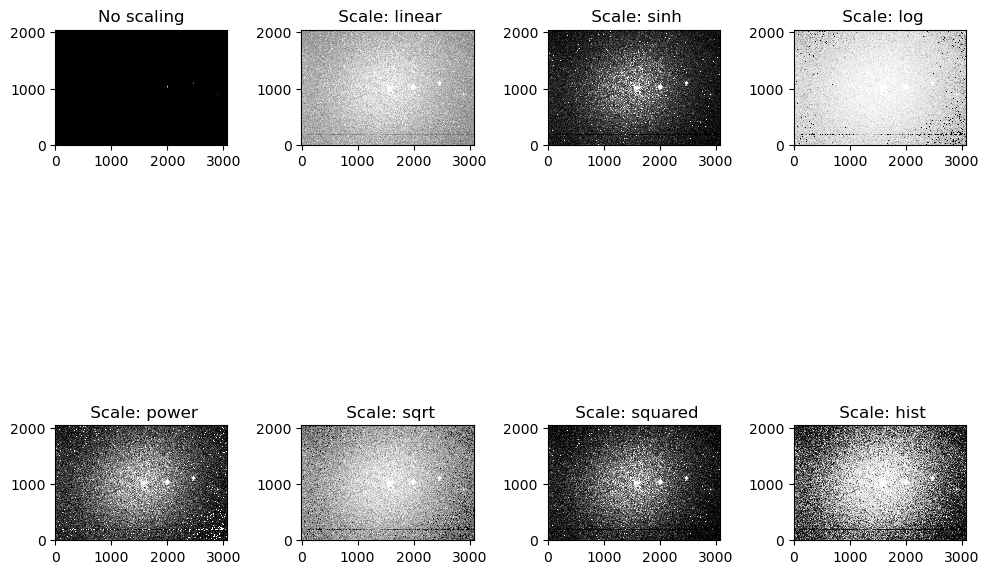

In [12]:
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
hdulist = fits.open('20210422_Li_.00000066.FIT')
data = hdulist[0].data

from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval
def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    """ This function goes over the data and put it into a plot.
    In the first part it checks if there are values for vmin and vmax, if there is not, is uses percentiles.
    In the second part it checks which stretch should be applied to the plot. """
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)
# We make a list of all the different scales, in order to address them to certain subplots later.
stretch_scales = ['linear', 'sinh', 'log', 'power', 'sqrt', 'squared', 'hist']
fig, axes = plt.subplots(2, 4, figsize = (10,10))
axes = axes.flatten()      # Same reason as the first question
# Use a for loop to assign the scales to subplots.
for i, s in enumerate(stretch_scales):
    imdisplay(data, ax = axes[i+1], scale = s)
    axes[i+1].set_title(f" Scale: {s}")
# To set the first plot, without scaling
axes[0].imshow(data, cmap = 'gray', origin = 'lower')
axes[0].set_title("No scaling")

plt.tight_layout()
plt.show()


In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

20220518.00000000.FIT


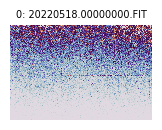

In [28]:
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
from pathlib import Path
data_dir = Path('.')   # We can do this since the folder is in the same directory as this notebook.
excludes = ['BIAS', 'FLAT', 'DARK', 'noisemap', 'm101']
path = data_dir
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)

# Print first 5 file names
for f in filepaths[:5]:
    print(f.name)

from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval


def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)
from matplotlib.pyplot import figure, show
from astropy.io import fits
from math import ceil

fig = figure(figsize=(8,6), tight_layout=True)
count = 1
ncols = 5
nrows = ceil(len(filepaths)/ncols)
for i, filepath in enumerate(filepaths):
    hdulist = fits.open(filepath)
    ax = fig.add_subplot(nrows, ncols, count)
    ax.axis('off')
    imdisplay(hdulist[0].data, ax, scale='power', power=3, cmap='twilight')
    ax.set_title(f"{i}: {filepath.name}", fontsize=7)
    count += 1
    hdulist.close()
show()

# I tried downloading a FIT file from the Blaauw website, but I only get this one image, so I don't know how to advance with the rest.

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")